# 🎨 TCS34725 센서 데이터 기반 MLP 색깔 분류 - 학습

**목표**: RGB 센서(TCS34725)로 측정한 데이터를 사용하여 MLP 모델 학습

**데이터**: 색깔 6종 × 50회 측정 = 300개 샘플
- 🔴 Red (빨강): 50개
- 🟠 Orange (주황): 50개
- 🟡 Yellow (노랑): 50개
- 🟢 Green (초록): 50개
- 🔵 Blue (파랑): 50개
- 🟣 Purple (보라): 50개

**모델**: PyTorch MLP (3 → 64 → 32 → 6)

In [6]:
# 필요한 라이브러리 import
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

In [8]:
# 📂 데이터 로드
data_dir = "./color_data"

# 병합된 파일 찾기 (all_로 시작하는 파일)
all_files = [f for f in os.listdir(data_dir) if f.startswith('all_') and f.endswith('.csv')]

if all_files:
    # 가장 최근 파일 사용
    latest_file = sorted(all_files)[-1]
    csv_path = f"{data_dir}/{latest_file}"
    print(f"📂 로드할 파일: {csv_path}")
else:
    # 개별 파일들 병합
    files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
    all_data = []
    for f in files:
        temp_df = pd.read_csv(f"{data_dir}/{f}")
        all_data.append(temp_df)
    df = pd.concat(all_data, ignore_index=True)
    csv_path = None
    print(f"📂 {len(files)}개 파일 병합")

if csv_path:
    df = pd.read_csv(csv_path)

print(f"\n총 샘플 수: {len(df)}개")
print(f"\n클래스별 분포:")
print(df['label'].value_counts())
df.head()

📂 로드할 파일: ./color_data/all_colors_rgb_data_20260121_215831.csv

총 샘플 수: 300개

클래스별 분포:
label
Blue      50
Green     50
Orange    50
Purple    50
Red       50
Yellow    50
Name: count, dtype: int64


,R,G,B,label
0,72,87,95,Blue
1,72,87,95,Blue
2,63,90,101,Blue
3,62,90,101,Blue
4,64,90,100,Blue


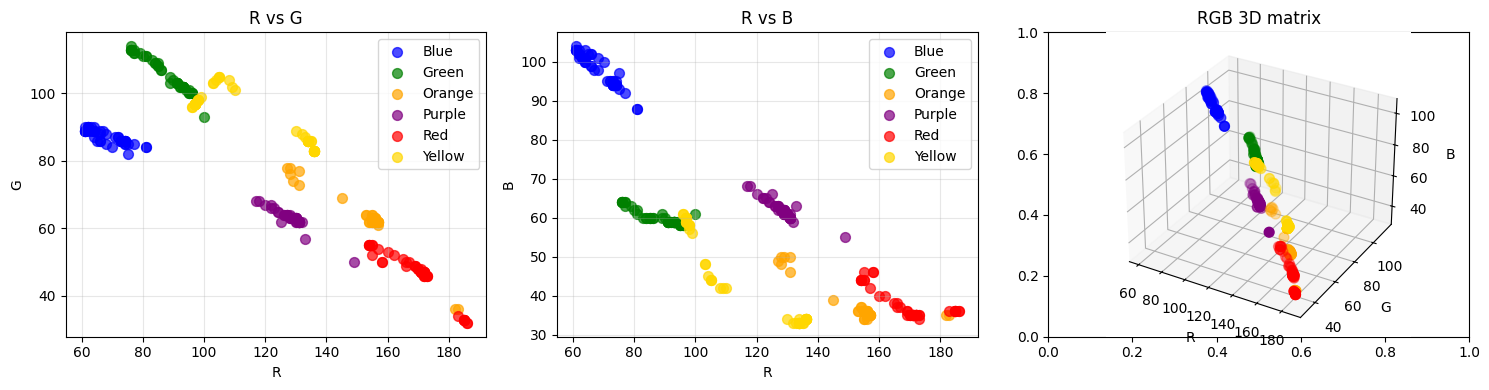


📊 클래스별 RGB 통계:
            R            G          B      
         mean   std   mean  std  mean   std
label                                      
Blue     68.6   5.8   87.1  2.0  97.8   4.2
Green    88.0   6.9  105.3  5.0  60.2   2.0
Orange  153.2  10.7   63.2  7.2  37.2   4.5
Purple  128.4   4.6   63.0  2.6  62.0   2.3
Red     169.4   9.3   46.6  6.7  37.5   3.7
Yellow  115.9  17.7   92.8  7.6  44.7  11.7


In [9]:
# 📈 데이터 분포 시각화
COLOR_NAMES = ['Red', 'Orange', 'Yellow', 'Green', 'Blue', 'Purple']
colors = {'Red': 'red', 'Orange': 'orange', 'Yellow': 'gold', 
          'Green': 'green', 'Blue': 'blue', 'Purple': 'purple'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# R vs G 산점도
for label in df['label'].unique():
    subset = df[df['label'] == label]
    axes[0].scatter(subset['R'], subset['G'], c=colors.get(label, 'gray'), label=label, s=50, alpha=0.7)
axes[0].set_xlabel('R')
axes[0].set_ylabel('G')
axes[0].set_title('R vs G')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# R vs B 산점도
for label in df['label'].unique():
    subset = df[df['label'] == label]
    axes[1].scatter(subset['R'], subset['B'], c=colors.get(label, 'gray'), label=label, s=50, alpha=0.7)
axes[1].set_xlabel('R')
axes[1].set_ylabel('B')
axes[1].set_title('R vs B')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3D 산점도
ax3d = fig.add_subplot(1, 3, 3, projection='3d')
for label in df['label'].unique():
    subset = df[df['label'] == label]
    ax3d.scatter(subset['R'], subset['G'], subset['B'], c=colors.get(label, 'gray'), label=label, s=50)
ax3d.set_xlabel('R')
ax3d.set_ylabel('G')
ax3d.set_zlabel('B')
ax3d.set_title('RGB 3D matrix')

plt.tight_layout()
plt.show()

# 통계 요약
print("\n📊 클래스별 RGB 통계:")
print(df.groupby('label')[['R', 'G', 'B']].agg(['mean', 'std']).round(1))

In [10]:
# 🔧 데이터 전처리
print("="*50)
print("Data Preprocessing")
print("="*50)

# Feature와 Label 분리
X = df[['R', 'G', 'B']].values.astype(np.float32)
y = df['label'].values

# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"클래스: {le.classes_}")
print(f"인코딩: {dict(zip(le.classes_, range(len(le.classes_))))}")

# 정규화 (0-255 → 0-1)
X_norm = X / 255.0

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)

print(f"\nX shape: {X_scaled.shape}")
print(f"X mean: {X_scaled.mean(axis=0).round(4)}")
print(f"X std: {X_scaled.std(axis=0).round(4)}")

Data Preprocessing
클래스: ['Blue' 'Green' 'Orange' 'Purple' 'Red' 'Yellow']
인코딩: {'Blue': 0, 'Green': 1, 'Orange': 2, 'Purple': 3, 'Red': 4, 'Yellow': 5}

X shape: (300, 3)
X mean: [ 0. -0. -0.]
X std: [1. 1. 1.]


In [11]:
# 📊 Train/Test 분할 (80/20)
print("="*50)
print("Train/Test Split")
print("="*50)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print(f"Train: {X_train.shape[0]}개 ({X_train.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]}개 ({X_test.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"\nTrain 클래스 분포: {np.bincount(y_train)}")
print(f"Test 클래스 분포:  {np.bincount(y_test)}")

# PyTorch 텐서로 변환
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("\n✓ DataLoader 생성 완료")

Train/Test Split
Train: 240개 (80%)
Test:  60개 (20%)

Train 클래스 분포: [40 40 40 40 40 40]
Test 클래스 분포:  [10 10 10 10 10 10]

✓ DataLoader 생성 완료


In [12]:
# 🧠 MLP 모델 정의
class ColorMLP(nn.Module):
    def __init__(self, input_dim=3, num_classes=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

# 모델 생성
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ColorMLP(input_dim=3, num_classes=6).to(device)

print(f"Device: {device}")
print(f"\n모델 구조:")
print(model)

# 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n총 파라미터: {total_params:,}")
print(f"학습 가능 파라미터: {trainable_params:,}")

Device: cuda

모델 구조:
ColorMLP(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=6, bias=True)
  )
)

총 파라미터: 2,534
학습 가능 파라미터: 2,534


In [13]:
# 🎯 모델 학습
print("="*50)
print("Training")
print("="*50)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

num_epochs = 300
train_losses = []
train_accs = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()
    
    scheduler.step()
    
    avg_loss = epoch_loss / len(train_loader)
    accuracy = 100. * correct / total
    train_losses.append(avg_loss)
    train_accs.append(accuracy)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] | Loss: {avg_loss:.4f} | Acc: {accuracy:.1f}%")

print(f"\n✓ 학습 완료! 최종 정확도: {train_accs[-1]:.1f}%")

Training
Epoch [ 50/300] | Loss: 0.0802 | Acc: 98.3%
Epoch [100/300] | Loss: 0.0570 | Acc: 97.9%
Epoch [150/300] | Loss: 0.0423 | Acc: 98.8%
Epoch [200/300] | Loss: 0.0326 | Acc: 98.8%
Epoch [250/300] | Loss: 0.0259 | Acc: 99.2%
Epoch [300/300] | Loss: 0.0262 | Acc: 99.2%

✓ 학습 완료! 최종 정확도: 99.2%


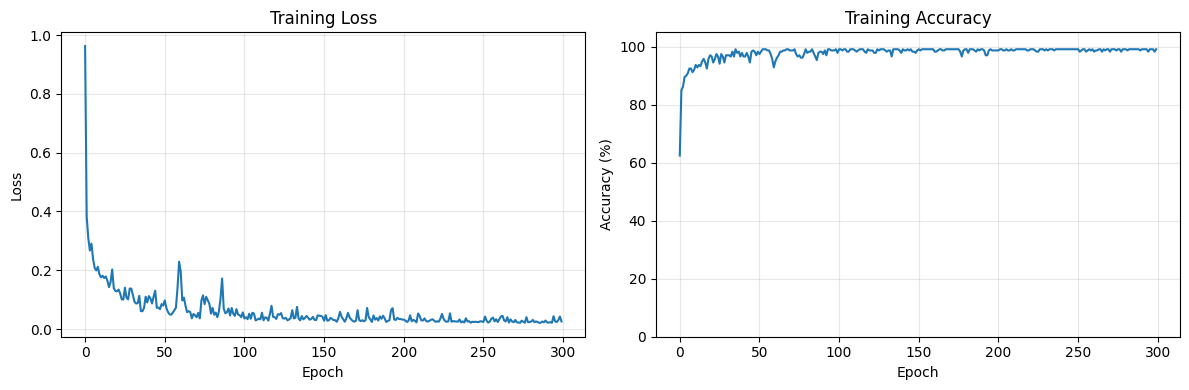

In [14]:
# 📈 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.show()

Test Evaluation
Test Accuracy: 100.00%

Confusion Matrix:
[[10  0  0  0  0  0]
 [ 0 10  0  0  0  0]
 [ 0  0 10  0  0  0]
 [ 0  0  0 10  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0 10]]

Classification Report:
              precision    recall  f1-score   support

        Blue       1.00      1.00      1.00        10
       Green       1.00      1.00      1.00        10
      Orange       1.00      1.00      1.00        10
      Purple       1.00      1.00      1.00        10
         Red       1.00      1.00      1.00        10
      Yellow       1.00      1.00      1.00        10

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



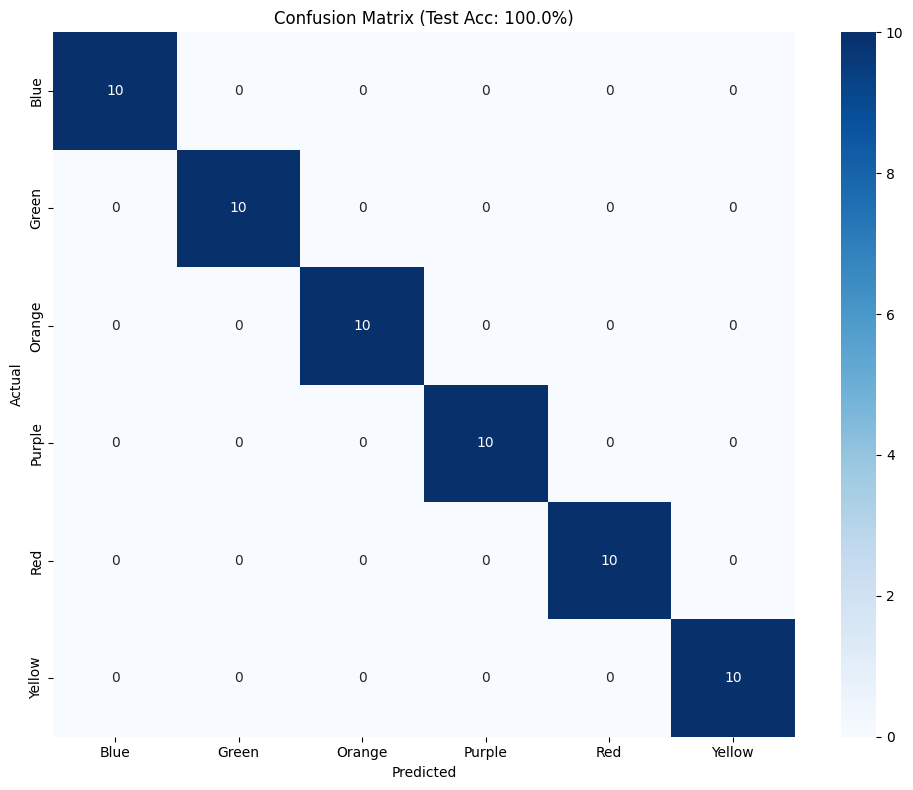

In [15]:
# 🧪 테스트 세트 평가
print("="*50)
print("Test Evaluation")
print("="*50)

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 정확도
test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc:.2%}")

# 혼동 행렬
cm = confusion_matrix(all_labels, all_preds)
print(f"\nConfusion Matrix:")
print(cm)

# Classification Report
print(f"\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

# 혼동 행렬 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Test Acc: {test_acc:.1%})')
plt.tight_layout()
plt.show()

In [18]:
# 📋 전체 데이터로 검증
print("="*50)
print(f"전체 데이터 검증 ({len(df)}개 샘플)")
print("="*50)

model.eval()
X_all = torch.FloatTensor(X_scaled).to(device)

with torch.no_grad():
    outputs = model(X_all)
    probs = torch.softmax(outputs, dim=1)
    _, predictions = outputs.max(1)

predictions = predictions.cpu().numpy()
probs = probs.cpu().numpy()

# 클래스별 정확도
correct_per_class = {}
total_per_class = {}

for i in range(len(df)):
    actual = le.classes_[y_encoded[i]]
    predicted = le.classes_[predictions[i]]
    
    if actual not in total_per_class:
        total_per_class[actual] = 0
        correct_per_class[actual] = 0
    
    total_per_class[actual] += 1
    if actual == predicted:
        correct_per_class[actual] += 1

emoji_map = {'Red': '🔴', 'Orange': '🟠', 'Yellow': '🟡', 
             'Green': '🟢', 'Blue': '🔵', 'Purple': '🟣'}

print("\n클래스별 정확도:")
total_correct = 0
for cls in le.classes_:
    if cls in total_per_class:
        acc = correct_per_class[cls] / total_per_class[cls]
        emoji = emoji_map.get(cls, '❓')
        print(f"  {emoji} {cls}: {correct_per_class[cls]}/{total_per_class[cls]} = {acc:.1%}")
        total_correct += correct_per_class[cls]

print(f"\n전체 정확도: {total_correct}/{len(df)} = {total_correct/len(df):.1%}")

전체 데이터 검증 (300개 샘플)

클래스별 정확도:
  🔵 Blue: 50/50 = 100.0%
  🟢 Green: 50/50 = 100.0%
  🟠 Orange: 48/50 = 96.0%
  🟣 Purple: 50/50 = 100.0%
  🔴 Red: 50/50 = 100.0%
  🟡 Yellow: 50/50 = 100.0%

전체 정확도: 298/300 = 99.3%


In [22]:
# 💾 모델 저장
print("="*50)
print("Model Saving")
print("="*50)

save_dir = "color_model"
os.makedirs(save_dir, exist_ok=True)

# 1. 모델 가중치 저장
torch.save(model.state_dict(), f"{save_dir}/color_mlp_weights.pth")

# 2. 전체 모델 저장
torch.save(model, f"{save_dir}/color_mlp_full.pth")

# 3. Scaler 저장
joblib.dump(scaler, f"{save_dir}/scaler.joblib")

# 4. LabelEncoder 저장
joblib.dump(le, f"{save_dir}/label_encoder.joblib")

# 5. 모델 정보 저장
model_info = {
    "input_dim": 3,
    "num_classes": 6,
    "class_names": list(le.classes_),
    "train_accuracy": train_accs[-1] / 100,
    "test_accuracy": test_acc,
    "num_samples": len(df),
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "architecture": "3 → 64 → 32 → 6",
}

with open(f"{save_dir}/model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)

print(f"✓ 저장 완료: {save_dir}/")
for f in os.listdir(save_dir):
    size = os.path.getsize(f"{save_dir}/{f}") / 1024
    print(f"  - {f}: {size:.1f} KB")

Model Saving
✓ 저장 완료: color_model/
  - color_mlp_full.pth: 14.9 KB
  - color_mlp_weights.pth: 13.1 KB
  - label_encoder.joblib: 0.5 KB
  - model_info.json: 0.5 KB
  - scaler.joblib: 0.6 KB


In [23]:
# 🔮 추론 함수 정의
CLASS_NAMES = list(le.classes_)
EMOJI_MAP = {'Red': '🔴', 'Orange': '🟠', 'Yellow': '🟡', 
             'Green': '🟢', 'Blue': '🔵', 'Purple': '🟣'}

def classify_color(r, g, b):
    """
    RGB 값을 받아 딥러닝 모델로 색깔 분류
    
    Args:
        r, g, b: RGB 값 (0~255)
    
    Returns:
        tuple: (색깔 이름, 신뢰도, 모든 클래스 확률)
    """
    # 전처리
    x = np.array([[r, g, b]], dtype=np.float32) / 255.0
    x = scaler.transform(x)
    
    # 추론
    x_tensor = torch.FloatTensor(x).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_idx = logits.argmax(dim=1).item()
        confidence = probs[0, pred_idx].item()
    
    label = CLASS_NAMES[pred_idx]
    all_probs = {CLASS_NAMES[i]: probs[0, i].item() for i in range(len(CLASS_NAMES))}
    
    return label, confidence, all_probs

# 테스트
print("="*60)
print("🔮 추론 함수 테스트")
print("="*60)

# 각 색깔별 평균값으로 테스트
test_cases = df.groupby('label')[['R', 'G', 'B']].mean().round().astype(int)

print(f"\n{'RGB':^15} | {'예측':^12} | {'신뢰도':>8}")
print("-" * 45)
for label, row in test_cases.iterrows():
    r, g, b = row['R'], row['G'], row['B']
    pred_label, conf, probs = classify_color(r, g, b)
    emoji = EMOJI_MAP.get(pred_label, '❓')
    result = "✅" if pred_label == label else "❌"
    print(f"({r:3},{g:3},{b:3}) | {emoji} {pred_label:<10} | {conf:7.1%} {result}")

🔮 추론 함수 테스트

      RGB       |      예측      |      신뢰도
---------------------------------------------
( 69, 87, 98) | 🔵 Blue       |  100.0% ✅
( 88,105, 60) | 🟢 Green      |  100.0% ✅
(153, 63, 37) | 🟠 Orange     |  100.0% ✅
(128, 63, 62) | 🟣 Purple     |  100.0% ✅
(169, 47, 37) | 🔴 Red        |   98.5% ✅
(116, 93, 45) | 🟡 Yellow     |  100.0% ✅


---
## 🚀 실시간 분류 (아두이노 연결)

In [24]:
# 🔌 시리얼 통신 설정
import serial
import serial.tools.list_ports
import time
import re

# 포트 확인
print("사용 가능한 시리얼 포트:")
for port in serial.tools.list_ports.comports():
    print(f"  • {port.device}: {port.description}")

SERIAL_PORT = "COM3"  # 실제 포트로 변경
BAUD_RATE = 9600

사용 가능한 시리얼 포트:
  • COM3: USB-SERIAL CH340(COM3)


In [25]:
# RGB 데이터 파싱 함수
def parse_rgb_data(line):
    """
    다양한 형식의 RGB 데이터를 파싱
    """
    # 형식: "R : 값 G : 값 B : 값"
    pattern = r'R\s*:\s*(\d+)\s*G\s*:\s*(\d+)\s*B\s*:\s*(\d+)'
    match = re.search(pattern, line, re.IGNORECASE)
    if match:
        r, g, b = int(match.group(1)), int(match.group(2)), int(match.group(3))
        return r, g, b
    
    # 형식: "값,값,값"
    if ',' in line:
        parts = line.split(',')
        if len(parts) >= 3:
            try:
                r, g, b = float(parts[0]), float(parts[1]), float(parts[2])
                return int(r), int(g), int(b)
            except:
                pass
    
    return None

In [27]:
#  실시간 분류 실행
def run_classification():
    """아두이노에서 RGB 값을 받아 실시간 분류"""
    
    try:
        ser = serial.Serial(SERIAL_PORT, BAUD_RATE, timeout=2)
        print(f"✓ 연결됨: {SERIAL_PORT} @ {BAUD_RATE} baud")
        print("="*60)
        print(" 사용법: 엔터를 누르면 RGB 1회 측정 후 분류합니다.")
        print(" 종료: 'q' 입력 후 엔터")
        print("="*60)
        
        time.sleep(2)
        ser.reset_input_buffer()
        count = 0
        
        while True:
            user_input = input("\n[엔터] 측정 시작 (q: 종료) > ").strip().lower()
            
            if user_input == 'q':
                print("\n 프로그램 종료")
                break
            
            ser.reset_input_buffer()
            print(" 측정 중...", end=" ", flush=True)
            
            measured = False
            for _ in range(10):
                if ser.in_waiting > 0:
                    line = ser.readline().decode('utf-8', errors='ignore').strip()
                    if line:
                        result = parse_rgb_data(line)
                        if result:
                            r, g, b = result
                            if 0 <= r <= 255 and 0 <= g <= 255 and 0 <= b <= 255:
                                label, conf, probs = classify_color(r, g, b)
                                count += 1
                                
                                emoji = EMOJI_MAP.get(label, '❓')
                                
                                print(f"\n{'='*60}")
                                print(f" 측정 결과 #{count}")
                                print(f"{'-'*60}")
                                print(f"  측정 RGB: ({r}, {g}, {b})")
                                print(f"{'-'*60}")
                                print(f"   분류 결과:  {label}")
                                print(f"   신뢰도: {conf:.1%}")
                                print(f"{'-'*60}")
                                print("  확률 분포:")
                                for color, prob in sorted(probs.items(), key=lambda x: -x[1]):
                                    bar = "█" * int(prob * 20)
                                    e = EMOJI_MAP.get(color, '❓')
                                    print(f"    {e} {color:10s} {bar} {prob:.1%}")
                                print(f"{'='*60}")
                                measured = True
                                break
                time.sleep(0.2)
            
            if not measured:
                print("\n⚠️ 데이터를 수신하지 못했습니다.")
                
    except serial.SerialException as e:
        print(f"✗ 연결 실패: {e}")
    except KeyboardInterrupt:
        print("\n\n⚠️ 사용자가 중단했습니다.")
    finally:
        if 'ser' in locals() and ser.is_open:
            ser.close()
            print(f"\n✓ 연결 종료 (총 {count}회 측정)")

# 실행
run_classification()

✓ 연결됨: COM3 @ 9600 baud
 사용법: 엔터를 누르면 RGB 1회 측정 후 분류합니다.
 종료: 'q' 입력 후 엔터
 측정 중... 
 측정 결과 #1
------------------------------------------------------------
  측정 RGB: (172, 47, 34)
------------------------------------------------------------
   분류 결과:  Red
   신뢰도: 99.2%
------------------------------------------------------------
  확률 분포:
    🔴 Red        ███████████████████ 99.2%
    🟠 Orange      0.8%
    🟣 Purple      0.0%
    🟢 Green       0.0%
    🔵 Blue        0.0%
    🟡 Yellow      0.0%
 측정 중... 
 측정 결과 #2
------------------------------------------------------------
  측정 RGB: (172, 47, 35)
------------------------------------------------------------
   분류 결과:  Red
   신뢰도: 98.9%
------------------------------------------------------------
  확률 분포:
    🔴 Red        ███████████████████ 98.9%
    🟠 Orange      1.1%
    🟣 Purple      0.0%
    🟢 Green       0.0%
    🔵 Blue        0.0%
    🟡 Yellow      0.0%
 측정 중... 
 측정 결과 #3
------------------------------------------------------------

In [21]:
# Green과 Orange 비교
print(df[df['label'].isin(['Green', 'Orange', 'Yellow'])].groupby('label')[['R','G','B']].describe())

           R                                                    G         ...  \
       count   mean       std   min   25%   50%   75%   max count   mean  ...   
label                                                                     ...   
Green   50.0  14.44  9.672515   4.0   7.0   8.5  24.0  33.0  50.0  16.68  ...   
Orange  50.0  10.66  3.520262   4.0   8.0  11.5  13.0  20.0  50.0   4.24  ...   
Yellow  50.0  15.20  2.030381  11.0  14.0  15.0  16.0  20.0  50.0   9.22  ...   

                       B                                              
         75%   max count  mean       std  min  25%  50%    75%   max  
label                                                                 
Green   30.5  42.0  50.0  9.62  7.855558  1.0  4.0  5.0  17.75  25.0  
Orange   5.0   8.0  50.0  2.36  0.827092  1.0  2.0  2.5   3.00   4.0  
Yellow  10.0  12.0  50.0  3.62  0.635353  2.0  3.0  4.0   4.00   5.0  

[3 rows x 24 columns]
